# Ejercicio: Análisis de Sentimiento con Amazon Reviews

**Instrucciones generales:**
* Accede al Teams para descargar el CSV (`AmazonReviewsDataSet.csv`). Está subido en la tarea.
* Utiliza los hiperparámetros que consideres.
* NADA de IA…

## Pregunta 1. (1 punto)
**Preparación y análisis.**
* Importar librerías
* Cargar el CSV (`AmazonReviewsDataSet.csv`)
* Analizar. ¿Cuántas filas y columnas tiene el dataset?
* ¿Está balanceado el dataset?
* Gráfico de cuántas reseñas hay por sentimiento

In [47]:
import csv
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM

In [48]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [49]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [50]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/PIA/UD7/AmazonReviewsDataSet.csv')
df.head()

,Review,Sentiment
0,Very unhappy with this purchase. Item arrived ...,negative
1,Really impressed with the quality. Will defini...,positive
2,Disappointed with this item. Quality is much w...,negative
3,Fantastic product quality. Exceeded my expecta...,positive
4,I am so happy with this purchase. It works gre...,positive


In [51]:
df.info()

# Filas 75 - Columnas 2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     75 non-null     object
 1   Sentiment  75 non-null     object
dtypes: object(2)
memory usage: 1.3+ KB


In [52]:
df.value_counts('Sentiment')

# Si esta perfectamente balanceado, todos los tipos de sentimientos tienen la misma cantidad

,count
Sentiment,
negative,25
neutral,25
positive,25


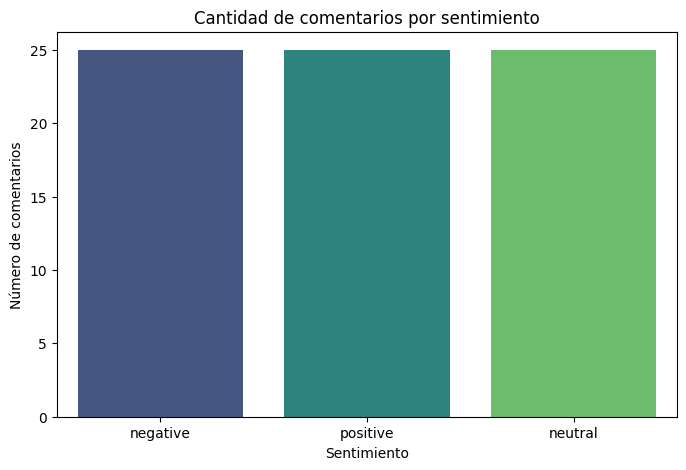

In [53]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(8, 5))

# Crear el gráfico de barras contando los valores de la columna 'Sentiment'
sns.countplot(data=df, x='Sentiment', hue='Sentiment', palette='viridis', legend=False)

# Añadir título y etiquetas a los ejes
plt.title('Cantidad de comentarios por sentimiento')
plt.xlabel('Sentimiento')
plt.ylabel('Número de comentarios')

# Mostrar el gráfico
plt.show()

## Pregunta 2. (1 punto)
**Preprocesamiento y limpieza del texto**
* Conversión a minúsculas
* Eliminación de signos de puntuación
* Eliminación de números
* Eliminación de stopwords
* Aplicar la limpieza de texto a todas las reseñas.

*(PISTA FINAL DOCUMENTO)*

In [54]:
df['Review'].isna().sum()

np.int64(0)

In [55]:
# Convertir a minúsculas
df['Review'] = df['Review'].str.lower()

# Eliminar signos de puntuación
df['Review'] = df['Review'].str.replace(r'[^\w\s]', '', regex=True)

# Eliminar números
df['Review'] = df['Review'].str.replace(r'\d+', '', regex=True)

# Eliminar stopwords
stop_words = set(stopwords.words('english'))

df['Review'] = df['Review'].fillna('')

df['Review'] = df['Review'].apply(
    lambda x: " ".join(word for word in x.split() if word not in stop_words)
)
df.head()

,Review,Sentiment
0,unhappy purchase item arrived broken packaging...,negative
1,really impressed quality definitely ordering p...,positive
2,disappointed item quality much worse shown pic...,negative
3,fantastic product quality exceeded expectation...,positive
4,happy purchase works great looks amazing,positive


## Pregunta 3. (0.5 puntos)
**Transformar etiquetas en valores numéricos**

Utiliza el siguiente código para esta parte:

In [56]:
# 1. Definir el diccionario con la equivalencia numérica
mapeo_sentimientos = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

# 2. Aplicar el mapeo
df['Sentiment'] = df['Sentiment'].map(mapeo_sentimientos)

# 3. Ver el cambio
print(df['Sentiment'].value_counts())

Sentiment
0    25
2    25
1    25
Name: count, dtype: int64


In [57]:
#le = LabelEncoder()
#df['label'] = le.fit_transform(df['Sentiment'])

In [58]:
df.head()

,Review,Sentiment
0,unhappy purchase item arrived broken packaging...,0
1,really impressed quality definitely ordering p...,2
2,disappointed item quality much worse shown pic...,0
3,fantastic product quality exceeded expectation...,2
4,happy purchase works great looks amazing,2


## Pregunta 4. (1 punto)
**Tokenizar y Padenizar.**
* Tokenizar.
* Imprime las 10 primeras palabras del vocabulario.
* Padenizar (padding).

In [59]:
stats = df['Review'].str.split().str.len().describe()
print(stats)

count    75.000000
mean      7.853333
std       1.111285
min       6.000000
25%       7.000000
50%       8.000000
75%       9.000000
max      10.000000
Name: Review, dtype: float64


In [60]:
vocab_size = 5000
max_length = 10
embedding_dim = 64
oov_tok = "<OOV>"
trunc_type = 'post'
padding_type = 'post'

##############

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(df['Review'])

word_index = tokenizer.word_index

In [61]:
dict(list(word_index.items())[0:10])

{'<OOV>': 1,
 'product': 2,
 'quality': 3,
 'works': 4,
 'nothing': 5,
 'arrived': 6,
 'purchase': 7,
 'item': 8,
 'average': 9,
 'great': 10}

## Pregunta 5. (1 punto)
**División del conjunto de datos y Modelo.**
* División del conjunto de datos: 80% entrenamiento y 20% prueba.
* Definición del modelo LSTM bidireccional.

In [62]:
train_sentences, test_sentences, train_labels, test_labels = train_test_split(
    df['Review'],
    df['Sentiment'],
    test_size=0.2,
    random_state=42
)

print(f"Entrenamiento: {len(train_sentences)} | Prueba: {len(test_sentences)}")

Entrenamiento: 60 | Prueba: 15


In [63]:
train_sequences = tokenizer.texts_to_sequences(train_sentences)
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

In [64]:
# 1. Definimos la parada anticipada
early_stop = EarlyStopping(
    monitor='val_loss',       # Vigilamos el error de validación
    patience=3,               # Si no mejora en 3 épocas, paramos
    restore_best_weights=True # Recupera el modelo de la mejor época (ej. la época 2)
)

model = tf.keras.Sequential([
    # Capa de entrada con las dimensiones
    tf.keras.layers.Embedding(vocab_size, embedding_dim),

    # LSTM Bidireccional con recurrent_dropout
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(embedding_dim,
                                                       return_sequences=False,
                                                       recurrent_dropout=0.2)),

    # Capas densas para clasificar
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Para evitar el sobreajuste

    # Capa de salida (Asumiendo clasificación binaria: Positivo/Negativo -> sigmoid)
    # Si tienes más de 2 categorías, usamos 'softmax' y cambiamos
    # el 1 por el número de etiquetas.
    tf.keras.layers.Dense(3, activation='softmax')
])

## Pregunta 6. (1 punto)
**Compilar y Entrenar.**
* Compilar el modelo.
* Entrenar el modelo con `validation_data`.

In [65]:
# Binaria -> binary_crossentropy
# Clasificación -> sparse_categorical_crossentropy

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [66]:
# Entrenamiento del modelo
history = model.fit(
    train_padded,               # Datos de entrenamiento
    train_labels,               # Etiquetas
    epochs=20,
    validation_data=(           # Datos para medir qué tan bien generaliza en cada vuelta
        test_padded,
        test_labels
    ),
    #callbacks=[early_stop],     # Para parar anticipadamente
    verbose=2                   # Muestra una línea de resumen por cada epoch
)

Epoch 1/20
2/2 - 9s - 4s/step - accuracy: 0.4667 - loss: 1.0961 - val_accuracy: 0.2000 - val_loss: 1.0993
Epoch 2/20
2/2 - 0s - 77ms/step - accuracy: 0.4333 - loss: 1.0922 - val_accuracy: 0.2000 - val_loss: 1.0997
Epoch 3/20
2/2 - 0s - 75ms/step - accuracy: 0.3167 - loss: 1.0992 - val_accuracy: 0.2000 - val_loss: 1.0984
Epoch 4/20
2/2 - 0s - 90ms/step - accuracy: 0.5667 - loss: 1.0846 - val_accuracy: 0.2000 - val_loss: 1.0966
Epoch 5/20
2/2 - 0s - 84ms/step - accuracy: 0.5333 - loss: 1.0763 - val_accuracy: 0.2000 - val_loss: 1.0945
Epoch 6/20
2/2 - 0s - 72ms/step - accuracy: 0.5167 - loss: 1.0678 - val_accuracy: 0.2000 - val_loss: 1.0914
Epoch 7/20
2/2 - 0s - 75ms/step - accuracy: 0.6000 - loss: 1.0597 - val_accuracy: 0.2667 - val_loss: 1.0866
Epoch 8/20
2/2 - 0s - 73ms/step - accuracy: 0.7000 - loss: 1.0487 - val_accuracy: 0.3333 - val_loss: 1.0805
Epoch 9/20
2/2 - 0s - 69ms/step - accuracy: 0.7500 - loss: 1.0307 - val_accuracy: 0.3333 - val_loss: 1.0709
Epoch 10/20
2/2 - 0s - 73ms/st

## Pregunta 7. (0.5 puntos)
**Visualización.**
* Representar la precisión del entrenamiento y validación.

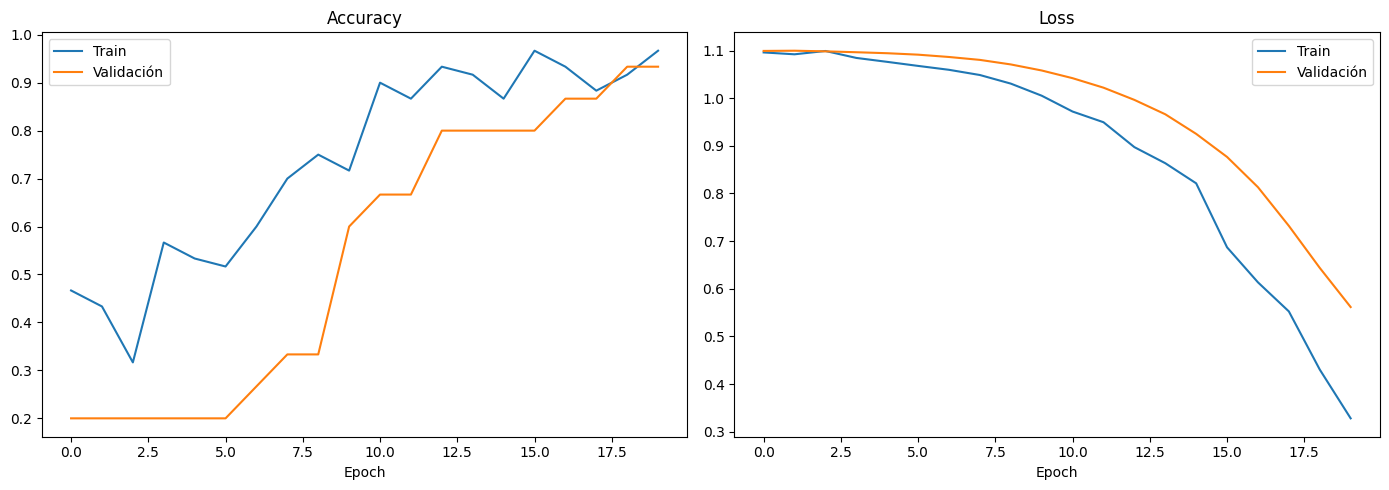

In [67]:
# Dibujar como ha ido el entrenamiento y la validación
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validación')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    # Loss
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validación')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

## Pregunta 8. (1.5 puntos)
**Predicción de sentimiento para nuevas reseñas de productos.**
* Prueba al menos con 5 reseñas inventadas por ti (positiva, negativa y neutral).

In [ ]:
# 5 reseñas inventadas: 2 positivas, 2 negativas, 1 neutra
ejemplos = [
    "Absolutely love this product! Best purchase ever, works perfectly every time.",  # positive
    "Great quality and fast shipping. Very happy with my order, highly recommend!",   # positive
    "Terrible product, broke on the first day. Complete waste of money, avoid!",       # negative
    "Very disappointed. Does not work as described and customer support is useless.",  # negative
    "It is okay, nothing special. Does the job but nothing to get excited about.",     # neutral
]


In [69]:
secuencias_nuevas = tokenizer.texts_to_sequences(ejemplos)

secuencias_padded = pad_sequences(
    secuencias_nuevas,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [70]:
predicciones = model.predict(secuencias_padded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step


In [71]:
clases_predichas = np.argmax(predicciones, axis=1)

In [72]:
print("-" * 50)
print("RESULTADOS DE LAS PREDICCIONES:")
print("-" * 50)

diccionario_sentimientos = {
    0: "Negativo",
    1: "Neutral",
    2: "Positivo"
}

for i, texto in enumerate(ejemplos):
    clase_num = clases_predichas[i]
    sentimiento = diccionario_sentimientos.get(clase_num, "Desconocido")

    # Calculamos qué tan seguro está el modelo (de 0 a 100%)
    seguridad = np.max(predicciones[i]) * 100

    print(f"Texto: '{texto}'")
    print(f"➜ Predicción: {sentimiento} (Clase {clase_num}) | Seguridad: {seguridad:.2f}%\n")

--------------------------------------------------
RESULTADOS DE LAS PREDICCIONES:
--------------------------------------------------
Texto: 'This iPhone is amazing, I wasn't expecting such quality!'
➜ Predicción: Neutral (Clase 1) | Seguridad: 56.00%

Texto: 'I thought it would be great, but honestly, I'm quite disappointed.'
➜ Predicción: Positivo (Clase 2) | Seguridad: 37.86%

Texto: 'Well, it wasn't bad, but at the same time, I wouldn't recommend it either'
➜ Predicción: Neutral (Clase 1) | Seguridad: 62.02%

Texto: 'After buying this, I feel like I completely wasted my money..'
➜ Predicción: Negativo (Clase 0) | Seguridad: 49.13%

Texto: 'I absolutely loved this product'
➜ Predicción: Neutral (Clase 1) | Seguridad: 43.80%

Texto: 'It had potential, but it just didn't live up to my expectations.'
➜ Predicción: Neutral (Clase 1) | Seguridad: 51.78%



## Pregunta 9. (1.5 puntos)
**Modificación y Comparación.**
* Modifica el modelo para añadir más capas LSTM y dropout.
* Compara los resultados con el modelo original. ¿Mejora o empeora?

In [73]:
model = tf.keras.Sequential([
    # Capa de entrada
    tf.keras.layers.Embedding(vocab_size, embedding_dim),

    # --- PRIMERA CAPA LSTM ---
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
        embedding_dim,
        return_sequences=True, # Debe ser True para pasar la secuencia a la siguiente LSTM
        dropout=0.2,           # Dropout para las transformaciones lineales de las entradas
        recurrent_dropout=0.2
    )),

    # --- NUEVA CAPA DROPOUT ENTRE LSTMs ---
    tf.keras.layers.Dropout(0.3), # Añadimos más regularización

    # --- SEGUNDA CAPA LSTM ---
    # Reducimos un poco la dimensionalidad (ej. a la mitad) suele ser buena práctica
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
        embedding_dim // 2,
        return_sequences=False, # Como es la ÚLTIMA capa LSTM, ahora sí es False
        dropout=0.2,
        recurrent_dropout=0.2
    )),

    # Capas densas para clasificar
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Para evitar el sobreajuste

    # Capa de salida (3 categorías)
    tf.keras.layers.Dense(3, activation='softmax')
])

In [74]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [75]:
# Entrenamiento del modelo
history_v2 = model.fit(
    train_padded,               # Datos de entrenamiento
    train_labels,               # Etiquetas
    epochs=20,
    validation_data=(           # Datos para medir qué tan bien generaliza en cada vuelta
        test_padded,
        test_labels
    ),
    #callbacks=[early_stop],     # Para parar anticipadamente
    verbose=2                   # Muestra una línea de resumen por cada epoch
)

Epoch 1/20
2/2 - 21s - 10s/step - accuracy: 0.3500 - loss: 1.0989 - val_accuracy: 0.2000 - val_loss: 1.1009
Epoch 2/20
2/2 - 2s - 1s/step - accuracy: 0.4000 - loss: 1.0945 - val_accuracy: 0.2000 - val_loss: 1.1044
Epoch 3/20
2/2 - 0s - 112ms/step - accuracy: 0.3500 - loss: 1.0960 - val_accuracy: 0.2000 - val_loss: 1.1060
Epoch 4/20
2/2 - 0s - 111ms/step - accuracy: 0.3833 - loss: 1.0938 - val_accuracy: 0.2000 - val_loss: 1.1055
Epoch 5/20
2/2 - 0s - 106ms/step - accuracy: 0.3833 - loss: 1.0871 - val_accuracy: 0.2000 - val_loss: 1.1029
Epoch 6/20
2/2 - 0s - 96ms/step - accuracy: 0.3833 - loss: 1.0835 - val_accuracy: 0.2000 - val_loss: 1.1005
Epoch 7/20
2/2 - 0s - 94ms/step - accuracy: 0.4833 - loss: 1.0703 - val_accuracy: 0.2000 - val_loss: 1.0954
Epoch 8/20
2/2 - 0s - 96ms/step - accuracy: 0.6167 - loss: 1.0682 - val_accuracy: 0.2000 - val_loss: 1.0898
Epoch 9/20
2/2 - 0s - 155ms/step - accuracy: 0.5333 - loss: 1.0588 - val_accuracy: 0.2000 - val_loss: 1.0822
Epoch 10/20
2/2 - 0s - 93m

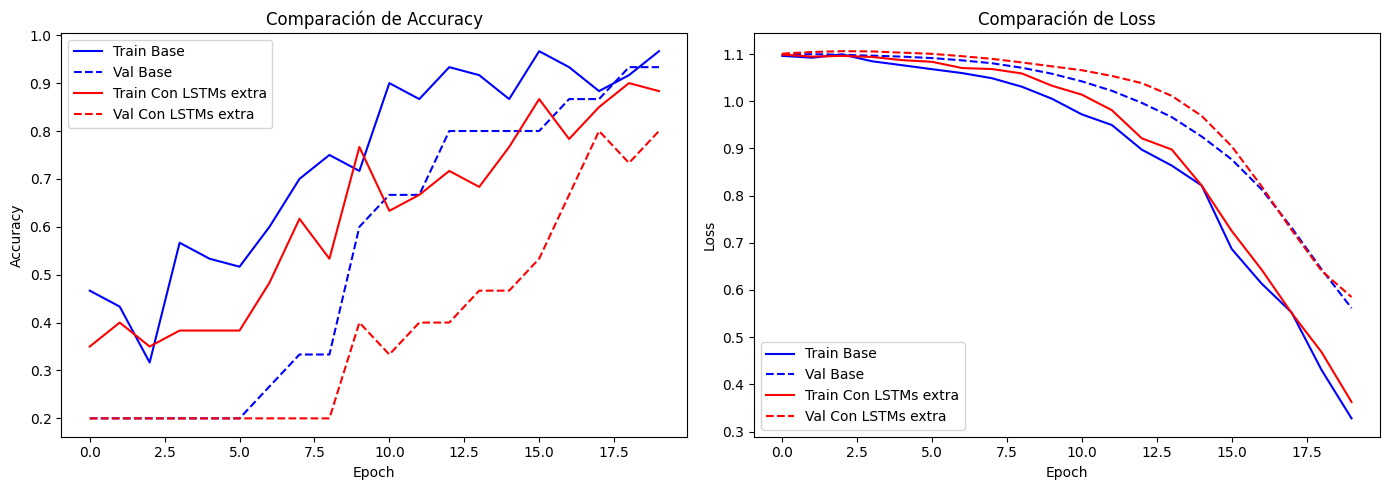

In [79]:
def plot_history_comparison(history1, history2, name1="Modelo 1", name2="Modelo 2"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Gráfica de Accuracy ---
    # Modelo 1 (ej: Azul)
    axes[0].plot(history1.history['accuracy'],     label=f'Train {name1}', color='blue')
    axes[0].plot(history1.history['val_accuracy'], label=f'Val {name1}',   color='blue', linestyle='--')

    # Modelo 2 (ej: Rojo)
    axes[0].plot(history2.history['accuracy'],     label=f'Train {name2}', color='red')
    axes[0].plot(history2.history['val_accuracy'], label=f'Val {name2}',   color='red', linestyle='--')

    axes[0].set_title('Comparación de Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # --- Gráfica de Loss ---
    # Modelo 1 (ej: Azul)
    axes[1].plot(history1.history['loss'],     label=f'Train {name1}', color='blue')
    axes[1].plot(history1.history['val_loss'], label=f'Val {name1}',   color='blue', linestyle='--')

    # Modelo 2 (ej: Rojo)
    axes[1].plot(history2.history['loss'],     label=f'Train {name2}', color='red')
    axes[1].plot(history2.history['val_loss'], label=f'Val {name2}',   color='red', linestyle='--')

    axes[1].set_title('Comparación de Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history_comparison(history, history_v2, "Base", "Con LSTMs extra")

## Pregunta 10. (1 punto)
**Conclusiones.**
* ¿Cómo mejorarías el ejercicio?
* ¿Qué dificultades has encontrado?

Para mejorar el ejercicio haría lo siguiente:

1. Buscar otro Dataset o crear datos sinteticos, 75 registros son muy pocos registros para enseñar a un modelo

Al ser tan pocos registros el modelo no aprende correctamente, luego no funciona correctamente

